In [1]:
import sys
sys.path.append("../")
from include import *
from analyzer_functions import *

In [2]:
# Defining system to work and all the paths to different files (Move to a config file later on)
rep_str = "1wave_9010/output/rep1"
rep_dir = get_path(sub_path=rep_str)
out_str = "1wave_9010/output/"
out_dir = get_path(sub_path=out_str)
calm_dir = get_path(main_path=rep_dir, sub_path="CALM")

# Raw filenames
xtc = "fixed.xtc"
pdb = "fixed.pdb"
tpr = "fixed.tpr"
box = "boxsize.npy"

Loading Data from: /home/danie/erda/1wave_9010/output/rep1/CALM/boxsize.npy
Loading Data from: /home/danie/erda/1wave_9010/output/rep1/CALM/curvature_frame_1_Upper.npy
Loading Data from: /home/danie/erda/1wave_9010/output/rep1/CALM/curvature_frame_1_Lower.npy


Text(0.5, 0.98, 'Curvature Landscape')

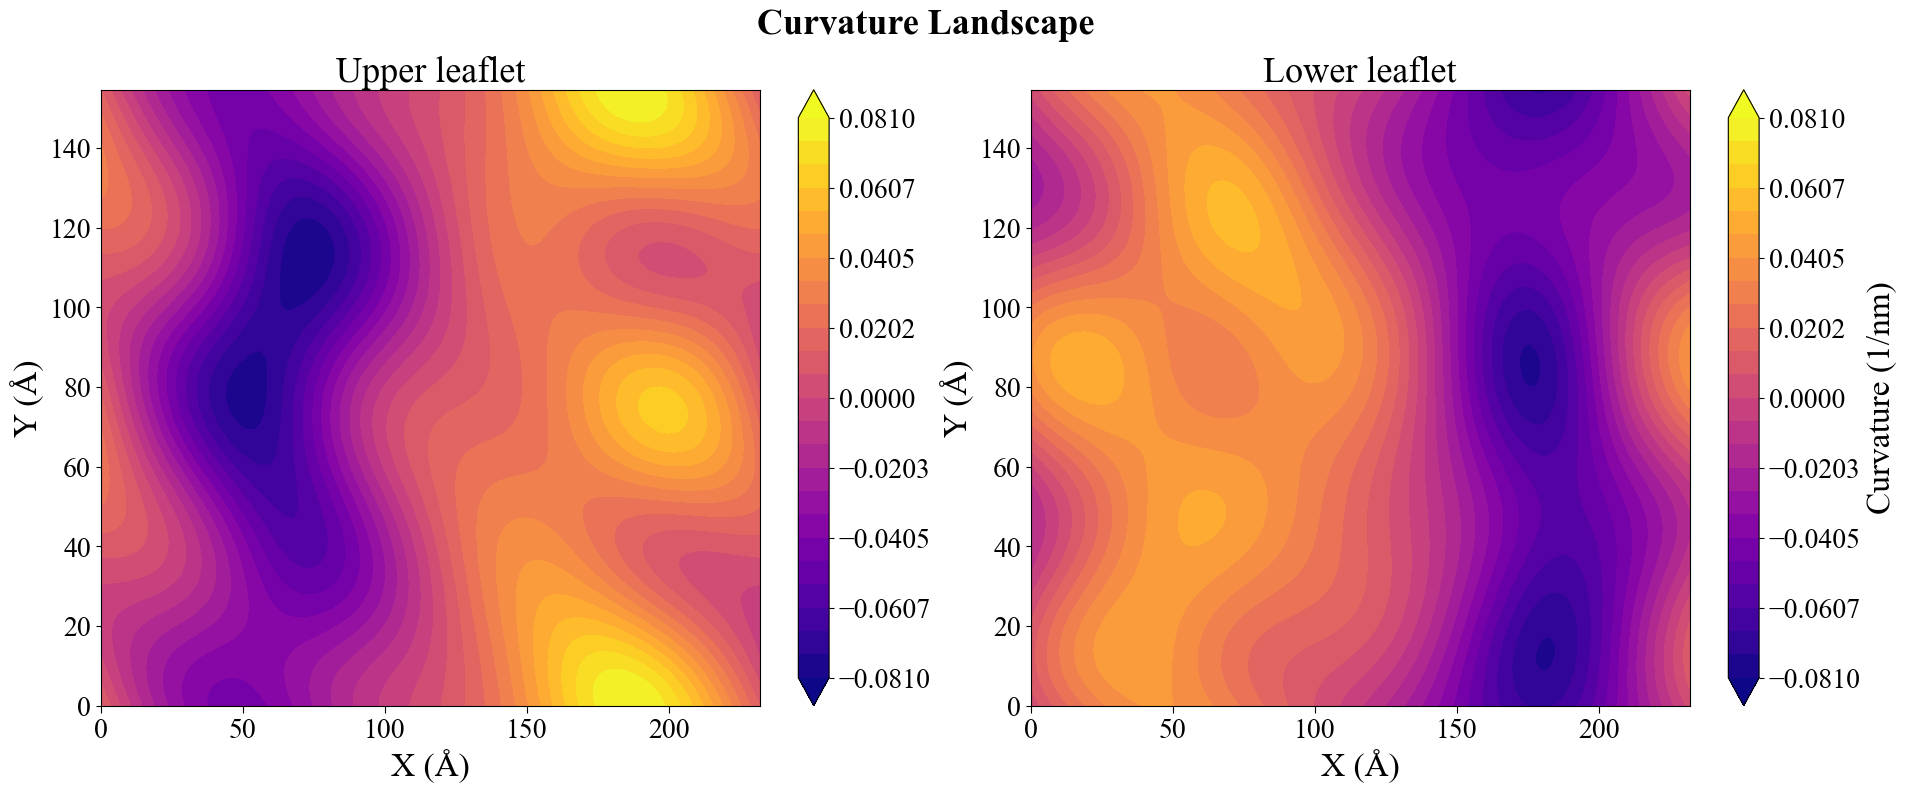

In [17]:
import matplotlib.colors as colors

boxsize = load_npy(calm_dir, box, verbose=True)
curv_upper = load_npy(calm_dir, "curvature_frame_1_Upper.npy", verbose=True)
curv_lower = -load_npy(calm_dir, "curvature_frame_1_Lower.npy", verbose=True)

max_curv = 0.081

norm = colors.Normalize(vmin=-max_curv, vmax=max_curv)
levels = np.linspace(-max_curv, max_curv, 25)

vmax = max(np.abs(curv_upper).max(), np.abs(curv_lower).max())
vmin = -vmax

fig, ax = plt.subplots(1, 2, figsize=(22, 8))

im0 = ax[0].contourf(curv_upper, cmap='plasma', levels=levels,
                    extent=[0, boxsize[0], 0, boxsize[1]],
                    norm=norm, extend='both')

ax[0].set_title("Upper leaflet", fontsize=26)
ax[0].set_xlabel("X (Å)", fontsize=24)
ax[0].set_ylabel("Y (Å)", fontsize=24)
ax[0].tick_params(labelsize=20)

im1 = ax[1].contourf(curv_lower, cmap='plasma', levels=levels,
                    extent=[0, boxsize[0], 0, boxsize[1]],
                    norm=norm, extend='both')

ax[1].set_title("Lower leaflet", fontsize=26)
ax[1].set_xlabel("X (Å)", fontsize=24)
ax[1].set_ylabel("Y (Å)", fontsize=24)
ax[1].tick_params(labelsize=20)

# Shared colorbar (better for comparison)
cbar = fig.colorbar(im0, ax=ax[0], orientation='vertical', fraction=0.1)
#cbar.set_label('Curvature (1/nm)', fontsize=24)
cbar.ax.tick_params(labelsize=20)


cbar = fig.colorbar(im1, ax=ax[1], orientation='vertical', fraction=0.1)
cbar.set_label('Curvature (1/nm)', fontsize=24)
cbar.ax.tick_params(labelsize=20)

fig.suptitle("Curvature Landscape", fontsize=26)

## Time Evolution plots of thermodynamic properties of a system (NOT FUNCTIONAL)

In [4]:
fname = "energy_eq_3SOL.xvg"
time, energy = load_xvg_file(fname, curr_run=curr_run)
time = time / 1000  # Convert time from ps to ns
cutoff = 0

plt.figure(figsize=(10, 6))
plt.plot(time[cutoff:], energy[cutoff:], color='blue')
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('Energy (kJ/mol)', fontsize=14)
plt.title('Energy vs Time', fontsize=16)
plt.grid()

NameError: name 'curr_run' is not defined

In [ ]:
# Inspecting the last equilibration step to catch any potential drifts in temperature, pressure, density, and volume
fnames = ["temp_eq_3SOL.xvg", "pressure_eq_3SOL.xvg", "density_eq_3SOL.xvg", "volume_eq_3SOL.xvg"]
x_labels = ['Time (ps)', 'Time (ps)', 'Time (ps)', 'Time (ps)']
y_labels = ['Temperature (K)', 'Pressure (bar)', 'Density (g/cm³)', 'Volume (nm³)']
colors = ['red', 'purple', 'blue', 'green']
title = 'NPT equilibration (eq_3)'

data_list = []
for fname in fnames:
    data_list.append(load_xvg_file(fname, curr_run=curr_run))

plot_grouped_data(data_list, x_axes=x_labels, y_axis=y_labels, title=title, colors=colors, figsize=(12, 8))